<a href="https://colab.research.google.com/github/emilceinfante/4GeeksAcademy/blob/4geeks/Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import pandas as pd
import cv2
import numpy as np
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


Contenido del directorio principal:
['train', 'test', '.ipynb_checkpoints']

■ Datos de entrenamiento (4915 imágenes):
label
1    2513
0    2402
Name: count, dtype: int64

■ Datos de prueba ({len(test_df)} imágenes):
label
0    1952
1    1922
Name: count, dtype: int64

Ejemplo de rutas:
Gato: /content/sample_data/cats_vs_dogs/train/cats/cat.125.jpg
Perro: /content/sample_data/cats_vs_dogs/train/dogs/dog.2175.jpg


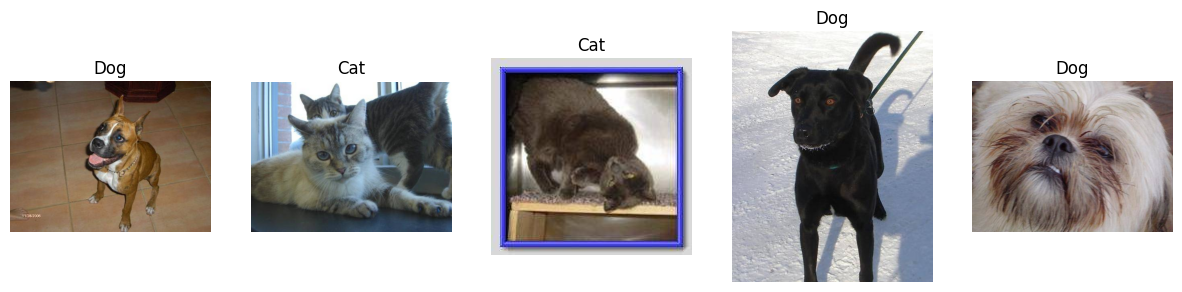

In [ ]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# 1. Conexión con la ruta en Codespace - IMPORTANTE: ¡Ajusta esta ruta!
base_path = "/content/sample_data/cats_vs_dogs"  # Cambia esto a tu ruta real
data_dir = base_path  # Asumiendo esta estructura

# 2. Verificación de la estructura de carpetas
print("Contenido del directorio principal:")
print(os.listdir(base_path))

# 3. Función para crear el DataFrame
def create_image_dataframe(root_dir):
    """
    Crea un dataframe con las rutas de imágenes y sus etiquetas
    Args:
        root_dir: Directorio con subcarpetas 'train' y 'test'
                  cada una con subcarpetas 'cats' y 'dogs'
    Returns:
        DataFrames (train_df, test_df)
    """
    datasets = ['train', 'test']
    dataframes = []

    for dataset in datasets:
        image_paths = []
        labels = []

        # Construir rutas para cada clase
        for label in ['cats', 'dogs']:
            class_dir = os.path.join(root_dir, dataset, label)

            # Verificar si la carpeta existe
            if not os.path.exists(class_dir):
                raise FileNotFoundError(f"No se encontró: {class_dir}")

            # Procesar cada imagen
            for image_name in os.listdir(class_dir):
                if image_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                    image_paths.append(os.path.join(class_dir, image_name))
                    labels.append(0 if label == 'cats' else 1)  # 0=cat, 1=dog

        # Crear DataFrame
        df = pd.DataFrame({
            'image_path': image_paths,
            'label': labels,
            'dataset': dataset  # Para identificar train/test
        })
        dataframes.append(df)

    return dataframes[0], dataframes[1]  # train_df, test_df

# 4. Crear los DataFrames
try:
    train_df, test_df = create_image_dataframe(data_dir)

    # Mostrar información de los datos
    print(f"\n■ Datos de entrenamiento ({len(train_df)} imágenes):")
    print(train_df['label'].value_counts())
    print("\n■ Datos de prueba ({len(test_df)} imágenes):")
    print(test_df['label'].value_counts())

    # Mostrar ejemplo de imágenes
    print("\nEjemplo de rutas:")
    print("Gato:", train_df[train_df['label'] == 0]['image_path'].iloc[0])
    print("Perro:", train_df[train_df['label'] == 1]['image_path'].iloc[0])

    # Guardar los dataframes (opcional)
    train_df.to_csv("/content/sample_data/train_data.csv", index=False)
    test_df.to_csv("/content/sample_data/test_data.csv", index=False)

except Exception as e:
    print(f"\n❌ Error: {str(e)}")
    print("Verifica la estructura de tus carpetas:")
    print("Debe ser: cats_vs_dogs/{train,test}/{cats,dogs}/[imágenes]")

# 5. Visualización de ejemplo
def show_sample_images(df, num_samples=5):
    """Muestra muestras de imágenes del dataframe"""
    plt.figure(figsize=(15, 5))
    samples = df.sample(num_samples)

    for i, (_, row) in enumerate(samples.iterrows()):
        img = Image.open(row['image_path'])
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.title("Cat" if row['label'] == 0 else "Dog")
        plt.axis('off')

    plt.show()

# Mostrar ejemplos (ejecutar solo si tienes interfaz gráfica)
try:
    show_sample_images(train_df)
except Exception as e:
    print("\n(No se pudo mostrar imágenes en este entorno)")
    print(f"Error: {str(e)}")


In [ ]:
import os
print("train_data.csv existe:", os.path.exists("/content/sample_data/train_data.csv"))
print("test_data.csv existe:", os.path.exists("/content/sample_data/test_data.csv"))


FileNotFoundError: [Errno 2] No such file or directory: 'content/sample_data/train_data.csv'

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

data = {
    'image_path': [
        '/content/sample_data/Dogs_vs_Cats/Train/cats',
        '/content/sample_data/Dogs_vs_Cats/Train/cats',
        '/content/sample_data/Dogs_vs_Cats/Train/dogs',
        '/content/sample_data/Dogs_vs_Cats/Train/dogs'
    ],
    'label': [0, 0, 1, 1]  # 0 para gatos, 1 para perros
}

df = pd.DataFrame(data)

# Definir X (características) y y (etiquetas)
X = df['image_path']  # Rutas de las imágenes
y = df['label']       # Etiquetas

# Dividir el DataFrame en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)




In [ ]:
!pip install tensorflow


 Inicialización y entrenamiento del modelo

In [ ]:
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import set_random_seed

set_random_seed(42)

model = Sequential([
    # Capa de entrada que define la forma de la imagen
    Input(shape=(28, 28)),  # Definir la forma de entrada
    # Capa que aplana la imagen de entrada de 28x28 píxeles a un vector de 784 elementos
    Flatten(),
    # Capa oculta densa con 128 neuronas y función de activación ReLU
    Dense(128, activation="relu"),
    # Capa de salida con 10 neuronas (una para cada dígito del 0 al 9)
    Dense(10)
])

# Resumen del modelo
model.summary()
